# XOPT - INTERPRETABLE METAHEURISTICS FOR COMBINATORIAL OPTIMIZATION

## MAX-p-CUT AND K-MEDOIDS CLUSTER CORRESPONDENCE (TOP 5%)

This notebook extends the original top-5% co-occurrence analysis by:

- computing **Max-p-Cut** clusters on the co-occurrence graph built from the elite long-term memory solutions;
- computing **p clusters with K-Medoids** directly from the original p-median instance;
- checking the **correspondence** between both clusterings;
- if every cluster contains exactly one facility from the reference best solution, using those facilities as anchors to detect which facilities migrate from one anchor to another.

### SETTING THE ENVIRONMENT

Importing the libraries:

In [1]:
import sys

from pathlib import Path


current_path = Path.cwd().resolve()
project_root = next(
    (
        path
        for path in [current_path, *current_path.parents]
        if (path / "pymedian").exists() and (path / "notebooks").exists()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Could not locate the project root from the current working directory."
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import xopt
import pymedian

import numpy    as np
import pandas   as pd
import seaborn  as sns
import matplotlib.pyplot as plt

from IPython.display       import display
from sklearn_extra.cluster import KMedoids
from scipy.optimize        import linear_sum_assignment
from sklearn.metrics       import normalized_mutual_info_score, adjusted_rand_score

This cell locates the "instances" folder in the project root and counts how many p-median instance files exist:

In [3]:
current_path = Path.cwd().resolve()

ROOT = next(
    (
        path
        for path in [current_path, *current_path.parents]
        if (path / "instances").exists() and (path / "pymedian").exists()
    ),
    None,
)

if ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root containing 'instances/' and 'pymedian/'."
    )


INSTANCES_DIR = ROOT / "instances"

print(f"Total number of p-median instances: {len(list(INSTANCES_DIR.glob('pmed[0-9]*.txt')))}")

Total number of p-median instances: 40


### APPLYING

We select a classic instance, solve it, recover the best solution stored in long-term memory, and keep the same **top-5% elite filtering** used in notebook `3.0.1`.

In [4]:
GLOBAL_SEED  = 42
TOP_FRACTION = 0.05


instance      = "pmed11.txt"
instance_path = str(INSTANCES_DIR / instance)

summary, details = pymedian.solve_pmedian(
    instance_path,
    restarts=8   ,
    max_iter=25  ,
    factor  =2   ,
)

p = int(summary["p"])
n = int(summary["n"])

long_term_memory = details["long_term_memory"]

if not long_term_memory:
    raise ValueError("long_term_memory is empty")

In [5]:
print(f"Instance {summary['instance'][:-4]} ({p}-{n})")

print()

print(f"  K-Medoids cost   : {summary['kmedoids_cost']}")
print(f"  TSPMED cost      : {summary['tspmed_cost'  ]}")
print(f"  Solutions in LTM : {summary['long_term_mem']}")

Instance /home/rei-luisinho/xopt/instances/pmed11 (5-300)

  K-Medoids cost   : 7696.0
  TSPMED cost      : 7696.0
  Solutions in LTM : 781


In [6]:
memory_rows = []

for idx, sol in enumerate(long_term_memory):
    binary          = np.asarray(sol["facilities"], dtype=int)
    facilities_zero = tuple(np.where(binary == 1)[0].tolist())

    memory_rows.append(
        {
            "solution_id"     : idx,
            "cost"            : float(sol["cost"]),
            "facilities_zero" : facilities_zero   ,
        }
    )

memory_df = pd.DataFrame(memory_rows)

best_row = memory_df.loc[
    memory_df["cost"].idxmin()
]

best_solution_id = int  (best_row["solution_id"])
best_cost        = float(best_row["cost"       ])

best_facilities = tuple(
    sorted(
        int(v)
        for v in best_row["facilities_zero"]
    )
)
best_set        = set  (best_facilities)

summary_best_facilities = tuple(
    sorted(
        idx - 1
        for idx in summary["tspmed_facilities"]
    )
)

top_solution_count = max(
    1, int(np.ceil(len(long_term_memory) * TOP_FRACTION))
)

analysis_long_term_memory = sorted(
    long_term_memory,
    key=lambda sol: sol["cost"]
)[:top_solution_count]

analysis_costs = np.array(
    [
        sol["cost"]
        for sol in analysis_long_term_memory
    ],
    dtype=float,
)


print(f"  Best solution in memory: S{best_solution_id}")
print(f"  Best cost in memory    :  {best_cost   :.1f}")
print(f"  Best facilities        :  {best_facilities }")

print()

print(f"Best facilities from summary and memory match: {summary_best_facilities == best_facilities}")
print(f"Analysis restricted to top {TOP_FRACTION:.0%}: {top_solution_count              } solutions")
print(f"Maximum cost kept in analysis: {analysis_costs.max():.1f}")

  Best solution in memory: S452
  Best cost in memory    :  7696.0
  Best facilities        :  (23, 30, 97, 166, 200)

Best facilities from summary and memory match: True
Analysis restricted to top 5%: 40 solutions
Maximum cost kept in analysis: 7739.0


Obtaining the problem instance and its distance matrix:

In [7]:
instance_obj = xopt.Instance(instance_path)

n_xopt = int(instance_obj.get_n())
p_xopt = int(instance_obj.get_p())

if n_xopt != n or p_xopt != p:
    raise ValueError(
        f"Inconsistency between pymedian and xopt: (n,p)=({n},{p}) vs ({n_xopt},{p_xopt})"
    )

distance_matrix = np.array(
    [
        [
            float(instance_obj[i, j])
            for j in range(n_xopt)
        ]
        for i in range(n_xopt)
    ],
    dtype=np.float64,
)

print(f"Distance matrix shape is {distance_matrix.shape}!")

Distance matrix shape is (300, 300)!


### FACILITY CO-OCCURRENCE NETWORK (TOP 5% BEST)

We build a co-occurrence adjacency matrix where entry `(i, j)` counts how often facilities `i` and `j` appear together inside the **top 5% best solutions** stored in long-term memory.

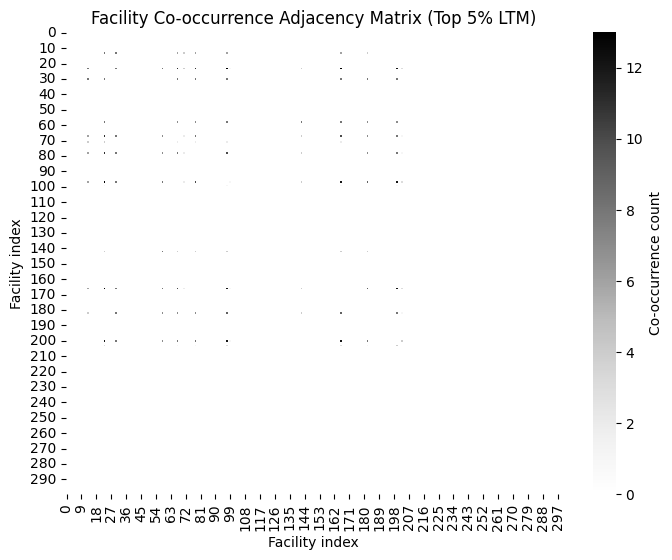

In [8]:
matrix = np.vstack(
    [
        np.asarray(sol["facilities"], dtype=int)
        for sol in analysis_long_term_memory
    ]
)

adjacency_matrix = np.zeros((n, n), dtype=int)

for sol in analysis_long_term_memory:
    facilities       = np.asarray(sol["facilities"], dtype=int)
    facility_indices = np.where(facilities == 1)[0]

    for i in range(len(facility_indices)):
        for j in range(i + 1, len(facility_indices)):
            idx_i = facility_indices[i]
            idx_j = facility_indices[j]

            adjacency_matrix[idx_i, idx_j] += 1
            adjacency_matrix[idx_j, idx_i] += 1


plt.figure(figsize=(8, 6))

sns.heatmap(
    adjacency_matrix,
    cmap    ="Greys",
    cbar_kws={"label": "Co-occurrence count"}
)

plt.title ("Facility Co-occurrence Adjacency Matrix (Top 5% LTM)")
plt.xlabel("Facility index")
plt.ylabel("Facility index")

plt.show()

### MAX-p-CUT CLUSTERS

We seek an **anti-community** structure in the elite co-occurrence graph: groups with weak internal connections and strong external ones. This is naturally modeled as a **Max-p-Cut** problem with `p` equal to the number of medians in the original p-median instance.

In [9]:
def _random_labels(n, p, rng):
    labels = rng.integers(0, p, size=n)

    if n >= p:
        perm             = rng.permutation(n)
        labels[perm[:p]] = np.arange(p)

    return labels


def _group_sums(A, labels, p):
    n    = A.shape[0]
    sums = np.zeros((n, p), dtype=float)

    for g in range(p):
        members = labels == g

        if np.any(members):
            sums[:, g] = A[:, members].sum(axis=1)

    return sums


def partition_weights(labels, A):
    same = labels[:, None] == labels[None, :]

    internal = float(np.triu(A * same, 1).sum())
    total    = float(np.triu(A, 1).sum())

    cut = total - internal

    return cut, internal


def max_p_cut_local_search(
    A,
    p,
    n_restarts=30  ,
    max_iter  =2000,
    seed      =42  ,
):
    A = np.asarray(A, dtype=float)

    n = A.shape[0]
    p = int(p)

    if p > n:
        p = n

    total_weight = float(np.triu(A, 1).sum())
    rng          = np.random.default_rng(seed)

    best_cut      = -np.inf
    best_internal =  np.inf
    best_labels   = None

    for _ in range(max(1, int(n_restarts))):
        labels = _random_labels(n, p     , rng)
        sums   = _group_sums   (A, labels, p  )

        internal = float(
            np.triu(
                A * (labels[:, None] == labels[None, :]),
                1
            ).sum()
        )
        cut = total_weight - internal

        for _ in range(max(1, int(max_iter))):
            improved = False

            for node in rng.permutation(n):
                old_group = labels[node]

                gains            = sums[node, old_group] - sums[node, :]
                gains[old_group] = -np.inf

                new_group = int  (np.argmax(gains))
                gain      = float(gains[new_group])

                if gain > 1e-12:
                    labels[node] = new_group
                    cut += gain

                    sums[:, old_group] -= A[:, node]
                    sums[:, new_group] += A[:, node]

                    improved = True

            if not improved:
                break

        internal = total_weight - cut

        if cut > best_cut + 1e-12:
            best_cut      = float(cut     )
            best_internal = float(internal)
            best_labels   = labels.copy()

    return best_labels, best_cut, best_internal


def internal_density(labels, A):
    _, internal = partition_weights(labels, A)

    sizes    = np.bincount(labels, minlength=p)
    possible = float(np.sum(sizes * (sizes - 1) / 2.0))

    if possible <= 0:
        return 0.0

    return internal / possible


def external_density(labels, A):
    cut, _ = partition_weights(labels, A)

    total_pairs = float(len(labels) * (len(labels) - 1) / 2.0)
    sizes       = np.bincount(labels, minlength=p)

    internal_pairs = float(np.sum(sizes * (sizes - 1) / 2.0))
    external_pairs = total_pairs - internal_pairs

    if external_pairs <= 0:
        return 0.0

    return cut / external_pairs


def summarize_clusters(labels, p, best_set):
    rows = []

    for cluster_id in range(p):
        members         = np.where(labels == cluster_id)[0]
        best_in_cluster = sorted  (best_set.intersection(members.tolist()))

        rows.append(
            {
                "cluster"          : cluster_id           ,
                "size"             : int(members.size)    ,
                "best_facilities"  : best_in_cluster      ,
                "preview_members"  : members[:15].tolist(),
            }
        )

    return pd.DataFrame(rows)

In [10]:
A = np.asarray(
    adjacency_matrix, dtype=float
).copy()

labels_maxcut, cut_weight, internal_weight = max_p_cut_local_search(
    A,
    p,
    n_restarts=30         ,
    max_iter  =2000       ,
    seed      =GLOBAL_SEED,
)

fraction_cut = cut_weight / (cut_weight + internal_weight + 1e-12)


print(f"=== Max-p-Cut Local Search (p = {p}) ===")

print()

print(f"Fraction cut     = {fraction_cut * 100:.2f}%")
print(f"Internal density = {internal_density(labels_maxcut, A) * 100:.2f}%")
print(f"External density = {external_density(labels_maxcut, A) * 100:.2f}%")

=== Max-p-Cut Local Search (p = 5) ===

Fraction cut     = 100.00%
Internal density = 0.00%
External density = 1.11%


In [11]:
maxcut_cluster_df = summarize_clusters(
    labels_maxcut, p, best_set
)

display(maxcut_cluster_df)

,cluster,size,best_facilities,preview_members
0,0,55,[30],"[4, 11, 12, 17, 30, 42, 50, 58, 59, 61, 64, 69..."
1,1,64,[166],"[0, 9, 20, 24, 31, 32, 35, 38, 48, 53, 62, 68,..."
2,2,56,[97],"[3, 5, 8, 10, 16, 19, 26, 27, 39, 41, 44, 45, ..."
3,3,64,[23],"[1, 2, 6, 22, 23, 28, 29, 34, 36, 37, 43, 46, ..."
4,4,61,[200],"[7, 13, 14, 15, 18, 21, 25, 33, 40, 47, 60, 70..."


In [12]:
print("Best facilities in Max-p-Cut clusters:")

for facility in best_facilities:
    print(f"  Facility {facility:3d} -> Cluster {int(labels_maxcut[facility])}")

Best facilities in Max-p-Cut clusters:
  Facility  23 -> Cluster 3
  Facility  30 -> Cluster 0
  Facility  97 -> Cluster 2
  Facility 166 -> Cluster 1
  Facility 200 -> Cluster 4


Compute the medoid for each max-p-cut cluster and the distances from each vertex to the medoid of its cluster:

In [13]:
cluster_ids = np.arange(p)

cluster_medoids          = {}
cluster_member_distances = []

for cluster_id in cluster_ids:
	members = np.where(labels_maxcut == cluster_id)[0]

	if len(members) == 0:
		continue

	subdist         = distance_matrix[np.ix_(members, members)]
	total_distances = subdist.sum(axis=1)

	best_pos      = int  (np.argmin(total_distances))
	medoid_vertex = int  (members        [best_pos ])
	medoid_cost   = float(total_distances[best_pos ])

	cluster_medoids[cluster_id] = {
		"medoid"          : medoid_vertex,
		"medoid_sum_dist" : medoid_cost  ,
		"cluster_size"    : int(len(members)),
	}

	for i, v in enumerate(members):
		cluster_member_distances.append(
			{
				"vertex"     : int(v)       ,
				"cluster_id" : cluster_id   ,
				"medoid"     : medoid_vertex,

				"vertex_sum_dist_in_cluster" : float(total_distances[i]               ),
				"dist_to_medoid"             : float(distance_matrix[v, medoid_vertex]),
			}
		)

cluster_medoids_df  = pd.DataFrame.from_dict(cluster_medoids, orient="index").reset_index().rename(columns={"index": "cluster_id"})
vertex_to_medoid_df = pd.DataFrame          (cluster_member_distances)

total_dist_to_medoid = vertex_to_medoid_df["dist_to_medoid"].sum()

print(f"Total sum of distances from all vertices to the medoid of their cluster: {total_dist_to_medoid:.2f}")

Total sum of distances from all vertices to the medoid of their cluster: 10332.00


### K-MEDOIDS CLUSTERS FROM THE ORIGINAL INSTANCE

Each facility is represented by its full **distance profile** to all facilities in the original p-median instance. We then apply **K-Medoids with `k = p`** on those profiles.

In [14]:
kmedoids = KMedoids(
    n_clusters  =p          ,
    random_state=GLOBAL_SEED,
)

labels_kmedoids = kmedoids.fit_predict(distance_matrix)


print(f"Inertia = {kmedoids.inertia_:.2f}")

Inertia = 66014.00


In [15]:
kmedoids_cluster_df = summarize_clusters(
    labels_kmedoids, p, best_set
)


print(f"=== K-Medoids on Distance Profiles (k = {p}) ===")
print()

display(kmedoids_cluster_df)

=== K-Medoids on Distance Profiles (k = 5) ===



,cluster,size,best_facilities,preview_members
0,0,76,[],"[1, 6, 14, 18, 24, 25, 32, 33, 34, 35, 36, 37,..."
1,1,56,[],"[2, 4, 5, 8, 11, 19, 20, 26, 27, 31, 39, 53, 6..."
2,2,65,"[97, 166, 200]","[0, 3, 10, 13, 15, 21, 40, 49, 50, 57, 58, 60,..."
3,3,67,[30],"[7, 17, 22, 29, 30, 41, 42, 43, 45, 48, 54, 55..."
4,4,36,[23],"[9, 12, 16, 23, 28, 56, 69, 70, 73, 84, 101, 1..."


In [16]:
print("Best facilities in K-Means clusters:")

for facility in best_facilities:
    print(f"  Facility {facility:3d} -> Cluster {int(labels_kmedoids[facility])}")

Best facilities in K-Means clusters:
  Facility  23 -> Cluster 4
  Facility  30 -> Cluster 3
  Facility  97 -> Cluster 2
  Facility 166 -> Cluster 2
  Facility 200 -> Cluster 2


### CORRESPONDENCE BETWEEN THE TWO CLUSTERINGS

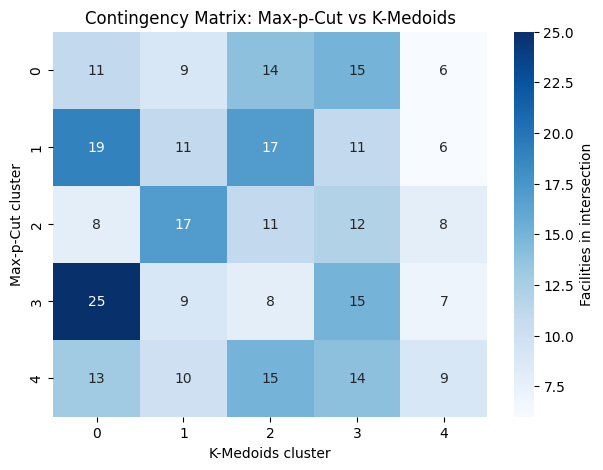

In [17]:
overlap_df = pd.crosstab(
    pd.Series(labels_maxcut  , name="max_p_cut"),
    pd.Series(labels_kmedoids, name="kmedoids "),
).reindex(index=range(p), columns=range(p), fill_value=0)

overlap_matrix = overlap_df.to_numpy(dtype=int)


plt.figure(figsize=(7, 5))

sns.heatmap(
    overlap_df,
    annot   =True   ,
    fmt     ="d"    ,
    cmap    ="Blues",
    cbar_kws={"label": "Facilities in intersection"},
)

plt.title ("Contingency Matrix: Max-p-Cut vs K-Medoids")
plt.xlabel("K-Medoids cluster")
plt.ylabel("Max-p-Cut cluster")

plt.show()

In [18]:
row_ind, col_ind = linear_sum_assignment(-overlap_matrix)

matched_pairs_df = pd.DataFrame(
    {
        "max_p_cut_cluster" : row_ind,
        "kmedoids_cluster"  : col_ind,
        "overlap"           : overlap_matrix[row_ind, col_ind],
    }
)

matched_pairs_df["max_p_cut_size"] = [int(np.sum(labels_maxcut   == cluster_id)) for cluster_id in matched_pairs_df["max_p_cut_cluster"]]
matched_pairs_df["kmedoids_size" ] = [int(np.sum(labels_kmedoids == cluster_id)) for cluster_id in matched_pairs_df["kmedoids_cluster" ]]

matched_pairs_df["overlap_rate_in_max_p_cut"] = matched_pairs_df["overlap"] / matched_pairs_df["max_p_cut_size"].clip(lower=1)
matched_pairs_df["overlap_rate_in_kmedoids" ] = matched_pairs_df["overlap"] / matched_pairs_df["kmedoids_size" ].clip(lower=1)


display(matched_pairs_df)

,max_p_cut_cluster,kmedoids_cluster,overlap,max_p_cut_size,kmedoids_size,overlap_rate_in_max_p_cut,overlap_rate_in_kmedoids
0,0,3,15,55,67,0.272727,0.223881
1,1,2,17,64,65,0.265625,0.261538
2,2,1,17,56,56,0.303571,0.303571
3,3,0,25,64,76,0.390625,0.328947
4,4,4,9,61,36,0.147541,0.250000


In [19]:
aligned_agreement = overlap_matrix[row_ind, col_ind].sum() / n

ari = adjusted_rand_score         (labels_maxcut, labels_kmedoids)
nmi = normalized_mutual_info_score(labels_maxcut, labels_kmedoids)


print(f"Aligned agreement rate = {aligned_agreement * 100:.2f}%")
print(f"Adjusted Rand Index    = {ari:.4f}")
print(f"Normalized Mutual Info = {nmi:.4f}")

Aligned agreement rate = 27.67%
Adjusted Rand Index    = 0.0065
Normalized Mutual Info = 0.0212


The reported values indicate that the partitions produced by **max-p-cut** and **k-medoids** are **almost unrelated**.

- **Aligned agreement rate = 27.67%**  
  After optimally matching cluster labels between the two methods, only **27.67% of the vertices** were assigned to corresponding clusters. This is a **low agreement level**, suggesting limited overlap between the two clusterings.

- **Adjusted Rand Index = 0.0065**  
  The **ARI** is extremely close to zero, which means that the two partitions show **almost no structural similarity beyond chance**. In practice, this indicates that the methods do not agree on which pairs of vertices should belong to the same cluster.

- **Normalized Mutual Info = 0.0212**  
  The **NMI** is also very close to zero, meaning that **knowing the cluster assignment from one method provides almost no information about the assignment from the other**.

Overall, these results show that **max-p-cut** and **k-medoids** are capturing **very different organizational principles** over the same set of facilities. In this context:

- **k-medoids** reflects **geometric similarity**, since it groups facilities according to their distance profiles in the original instance;
- **max-p-cut** reflects a **functional or anti-community structure**, since it separates facilities based on co-occurrence patterns in elite solutions.

Therefore, the low agreement between the two methods suggests that the structure emerging from elite solutions **cannot be explained solely by the original distance matrix**. Instead, it points to a different and potentially more interpretable organization related to the combinatorial behavior of high-quality solutions.

### ANCHORING CLUSTERS BY THE BEST-SOLUTION FACILITIES

If each cluster contains **exactly one** facility from the reference best solution, we can use that facility as an interpretable anchor for the cluster. Then a facility that is in the cluster of best facility `x` under Max-p-Cut and in the cluster of best facility `y` under K-Medoids is interpreted as moving from anchor `x` to anchor `y`.

In [20]:
def anchor_clusters_by_best_facility(labels, best_facilities, p, method_name):
    rows    = []
    mapping = {}
    valid   = True

    used_best = set()
    best_set  = set(best_facilities)

    for cluster_id in range(p):
        members         = np.where(labels == cluster_id)[0]
        best_in_cluster = sorted  (best_set.intersection(members.tolist()))

        if len(best_in_cluster) == 1:
            anchor              = int(best_in_cluster[0])
            mapping[cluster_id] = anchor

            used_best.add(anchor)
        else:
            anchor = None
            valid  = False

        rows.append(
            {
                "method"                 : method_name,
                "cluster"                : cluster_id ,
                "size"                   : int(members.size),
                "best_facilities_inside" : best_in_cluster  ,
                "anchor_best_facility"   : anchor           ,
            }
        )

    if used_best != set(best_facilities):
        valid = False

    return pd.DataFrame(rows), mapping, valid


maxcut_anchor_df  , maxcut_anchor_map  , maxcut_valid   = anchor_clusters_by_best_facility(labels_maxcut  , best_facilities, p, "max_p_cut")
kmedoids_anchor_df, kmedoids_anchor_map, kmedoids_valid = anchor_clusters_by_best_facility(labels_kmedoids, best_facilities, p, "kmedoids" )

print(f"Max-p-Cut anchoring valid: {maxcut_valid  }")
print(f"K-Medoids anchoring valid: {kmedoids_valid}")

Max-p-Cut anchoring valid: True
K-Medoids anchoring valid: False


In [21]:
anchors_df = pd.concat(
    [
        maxcut_anchor_df  ,
        kmedoids_anchor_df,
    ],
    ignore_index=True
)

display(anchors_df)

,method,cluster,size,best_facilities_inside,anchor_best_facility
0,max_p_cut,0,55,[30],30.0
1,max_p_cut,1,64,[166],166.0
2,max_p_cut,2,56,[97],97.0
3,max_p_cut,3,64,[23],23.0
4,max_p_cut,4,61,[200],200.0
5,kmedoids,0,76,[],NaN
6,kmedoids,1,56,[],NaN
7,kmedoids,2,65,"[97, 166, 200]",NaN
8,kmedoids,3,67,[30],30.0
9,kmedoids,4,36,[23],23.0


In [22]:
def assign_facilities_to_medians(distance_matrix, medians_zero):
    medians = np.array(
        sorted(
            {
                int(v)
                for v in medians_zero
            }
        ),
        dtype=np.int64
    )

    subset      = distance_matrix[:, medians]
    nearest_pos = np.argmin(subset, axis=1)

    assigned_median   = medians[nearest_pos]
    assigned_distance = subset[np.arange(subset.shape[0]), nearest_pos]

    return assigned_median, assigned_distance


if maxcut_valid and kmedoids_valid:
    optimal_assigned_median, optimal_assigned_distance = assign_facilities_to_medians(
        distance_matrix, best_facilities
    )

    comparison_df = pd.DataFrame(
        {
            "facility"                : np.arange(n, dtype=int),
            "is_best_facility"        : [facility in best_set for facility in range(n)],

            "optimal_nearest_best"    : optimal_assigned_median.astype(int),

            "max_p_cut_anchor"        : [maxcut_anchor_map  [int(labels_maxcut  [i])] for i in range(n)],
            "kmedoids_anchor"         : [kmedoids_anchor_map[int(labels_kmedoids[i])] for i in range(n)],
            "optimal_assignment_cost" : optimal_assigned_distance.astype(float),
        }
    )

    comparison_df["changed_between_clusterings"] = comparison_df["max_p_cut_anchor"] != comparison_df["kmedoids_anchor"]

    comparison_df["max_p_cut_differs_from_optimal_assignment"] = comparison_df["max_p_cut_anchor"] != comparison_df["optimal_nearest_best"]
    comparison_df["kmedoids_differs_from_optimal_assignment" ] = comparison_df["kmedoids_anchor" ] != comparison_df["optimal_nearest_best"]

    comparison_df["movement"] = comparison_df.apply(
        lambda row: f"{row['max_p_cut_anchor']} -> {row['kmedoids_anchor']}",
        axis=1,
    )

    changed_facilities_df = comparison_df[
        (~comparison_df["is_best_facility"           ]) &
        ( comparison_df["changed_between_clusterings"])
    ].copy()

    transition_summary_df = (
        changed_facilities_df
        .groupby    (["max_p_cut_anchor", "kmedoids_anchor"], as_index=False)
        .size       ()
        .rename     (columns={"size": "moved_facilities"}   )
        .sort_values(["max_p_cut_anchor", "kmedoids_anchor"])
        .reset_index(drop=True)
    )

    print(f"Facilities that change anchor between the two clusterings: {len(changed_facilities_df)}")
    print()

    if changed_facilities_df.empty:
        print("No non-best facility changes anchor when comparing Max-p-Cut and K-Medoids.")
    else:
        display(
            changed_facilities_df[
                [
                    "facility"                                 ,
                    "optimal_nearest_best"                     ,
                    "max_p_cut_anchor"                         ,
                    "kmedoids_anchor"                          ,
                    "movement"                                 ,
                    "max_p_cut_differs_from_optimal_assignment",
                    "kmedoids_differs_from_optimal_assignment" ,
                ]
            ]
            .sort_values(["max_p_cut_anchor", "kmedoids_anchor", "facility"])
            .reset_index(drop=True)
        )

        display(transition_summary_df)
else:
    print("Anchor-based migration analysis skipped.")
    print("Reason: at least one clustering does not place exactly one best facility inside every cluster.")

Anchor-based migration analysis skipped.
Reason: at least one clustering does not place exactly one best facility inside every cluster.
